In [1]:
!pip install kaggle
!pip install tensorflow matplotlib

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

In [4]:
!pip install kaggle tensorflow matplotlib

In [11]:
import json

kaggle_token = {
    "username": "",
    "key": ""
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_token, f)

In [12]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [13]:
!pip install kaggle

In [14]:
!kaggle competitions download -c cassava-leaf-disease-classification

100% 5.76G/5.76G [00:32<00:00, 192MB/s]



In [15]:
!unzip -q cassava-leaf-disease-classification.zip

In [16]:
import os
print(os.listdir())

['.config', 'cassava-leaf-disease-classification.zip', 'test_tfrecords', 'sample_submission.csv', 'train.csv', 'train_tfrecords', 'kaggle.json', 'label_num_to_disease_map.json', 'train_images', 'test_images', 'sample_data']


In [17]:
import pandas as pd
import os
import shutil

df = pd.read_csv("train.csv")

os.makedirs("data", exist_ok=True)

for i in range(len(df)):
    img = df.loc[i, "image_id"]
    label = str(df.loc[i, "label"])

    label_folder = os.path.join("data", label)
    os.makedirs(label_folder, exist_ok=True)

    src = os.path.join("train_images", img)
    dst = os.path.join(label_folder, img)

    if os.path.exists(src):
        shutil.copy(src, dst)

print("Dataset Ready ✅")

Dataset Ready ✅


In [18]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "data",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "data",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

Found 21397 files belonging to 5 classes.
Using 17118 files for training.
Found 21397 files belonging to 5 classes.
Using 4279 files for validation.


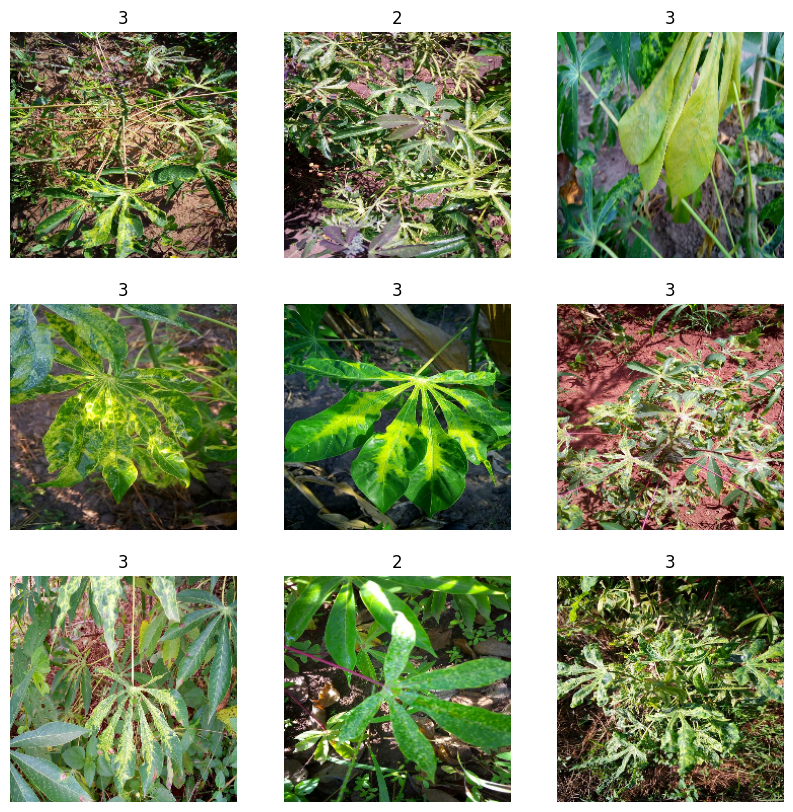

In [19]:
import matplotlib.pyplot as plt

class_names = train_ds.class_names

plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [20]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

In [21]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 91s 155ms/step - accuracy: 0.6092 - loss: 1.1897 - val_accuracy: 0.6207 - val_loss: 1.0564
Epoch 2/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 78s 145ms/step - accuracy: 0.6390 - loss: 0.9937 - val_accuracy: 0.6153 - val_loss: 1.0303
Epoch 3/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 78s 138ms/step - accuracy: 0.7066 - loss: 0.7978 - val_accuracy: 0.6251 - val_loss: 1.1957
Epoch 4/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 81s 136ms/step - accuracy: 0.8493 - loss: 0.4180 - val_accuracy: 0.6132 - val_loss: 1.8275
Epoch 5/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 81s 135ms/step - accuracy: 0.9475 - loss: 0.1587 - val_accuracy: 0.5985 - val_loss: 2.2910


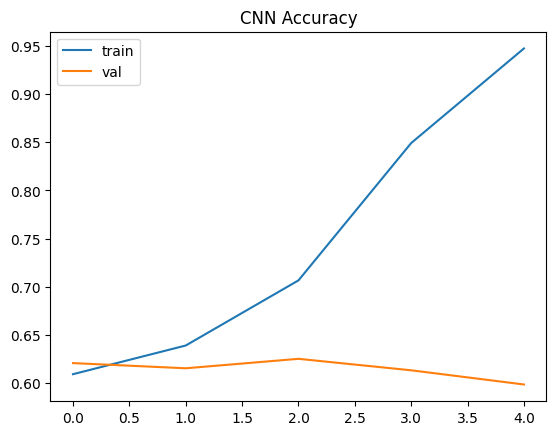

In [22]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("CNN Accuracy")
plt.show()

In [23]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model2 = models.Sequential([
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [24]:
model2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

history2 = model2.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 115s 177ms/step - accuracy: 0.6940 - loss: 0.8342 - val_accuracy: 0.7046 - val_loss: 0.7877
Epoch 2/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 73s 137ms/step - accuracy: 0.7369 - loss: 0.7135 - val_accuracy: 0.7083 - val_loss: 0.7897
Epoch 3/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 74s 138ms/step - accuracy: 0.7542 - loss: 0.6691 - val_accuracy: 0.7217 - val_loss: 0.7719
Epoch 4/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 65s 121ms/step - accuracy: 0.7695 - loss: 0.6327 - val_accuracy: 0.7303 - val_loss: 0.7451
Epoch 5/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 74s 138ms/step - accuracy: 0.7788 - loss: 0.5974 - val_accuracy: 0.7203 - val_loss: 0.7714


In [26]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model2 = models.Sequential([
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

In [27]:
model2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

history2 = model2.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 87s 146ms/step - accuracy: 0.7015 - loss: 0.8242 - val_accuracy: 0.7123 - val_loss: 0.7627
Epoch 2/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 74s 138ms/step - accuracy: 0.7391 - loss: 0.7089 - val_accuracy: 0.7252 - val_loss: 0.7395
Epoch 3/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 81s 137ms/step - accuracy: 0.7565 - loss: 0.6663 - val_accuracy: 0.7333 - val_loss: 0.7276
Epoch 4/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 81s 136ms/step - accuracy: 0.7667 - loss: 0.6334 - val_accuracy: 0.7338 - val_loss: 0.7415
Epoch 5/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 73s 120ms/step - accuracy: 0.7827 - loss: 0.5965 - val_accuracy: 0.7217 - val_loss: 0.7773


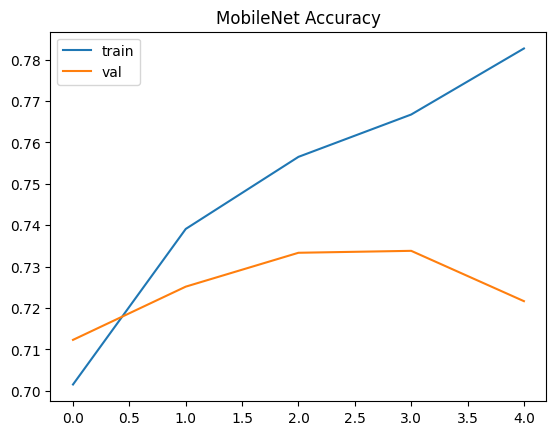

In [28]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("MobileNet Accuracy")
plt.show()